# Comparison of our influence metric: linear vs. non-linear

The goal of this notebook is to compare our influence metric from the linear case to the non-linear case.

In [2]:
import statsmodels.api as sm
from statsmodels.stats import outliers_influence
from statsmodels.formula.api import ols

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import shap

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from main_iom import *

In [4]:
sns.set_theme(style='white')

## OLS

We read in the data, fit the linear model and calculate SHAP values. 

In [5]:
data = sm.datasets.get_rdataset("Duncan", "carData").data

In [6]:
mod = ols("prestige ~ income", data=data).fit()

Caluclate Cook's distance and $p$-value.

In [7]:
pd.concat([outliers_influence.OLSInfluence(mod).cooks_distance[0], 
           pd.Series(outliers_influence.OLSInfluence(mod).cooks_distance[1], name='pval', index=data.index)], axis=1) \
                .sort_values(['pval'])

,0,pval
rownames,,
conductor,0.273524,0.762008
minister,0.265244,0.768265
RR.engineer,0.082942,0.920552
reporter,0.043817,0.957171
professor,0.033585,0.966998
streetcar.motorman,0.031903,0.968623
chemist,0.024828,0.975492
insurance.agent,0.021963,0.978287
physician,0.019501,0.980696


Do not reject that there are no influential outliers at the $\alpha=0.05$ confidence level.

In [8]:
X = data[['income']]
y = data['prestige']

# a simple linear model
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


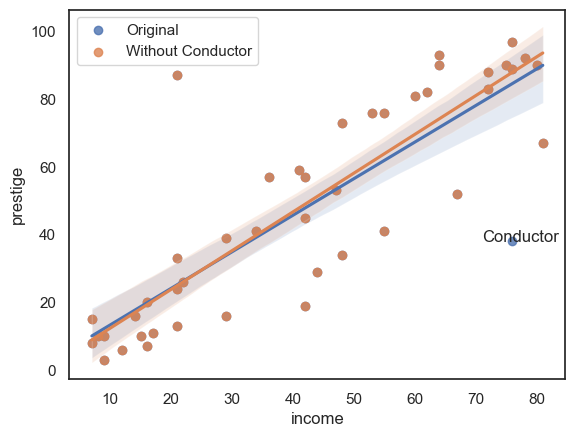

In [9]:
sns.regplot(data, x="income", y="prestige", label='Original')
sns.regplot(data.drop("conductor"), x="income", y="prestige", label='Without Conductor')
plt.annotate("Conductor", (data.loc["conductor", "income"]-5, data.loc["conductor", "prestige"]), fontsize=12)
plt.legend()

Calculate the residuals.

In [10]:
resid = np.array(y - model.predict(X))

And the SHAP values.

In [11]:
explainer = shap.LinearExplainer(model, X)
shap_values = explainer(X).values

## Random Forest

We fit the data with the Random Forest and calculate SHAP values.

In [12]:
clf = RandomForestRegressor(max_depth=2, random_state=0)
clf.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
clf_2 = RandomForestRegressor(max_depth=2, random_state=0)
clf_2.fit(X.drop("conductor"), y.drop("conductor"))

,n_estimators,100
,criterion,'squared_error'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
Pred = pd.concat([X.reset_index(drop=True), pd.Series(clf.predict(X))], axis=1, ignore_index=True).sort_values(0)
Pred_2 = pd.concat([X.drop("conductor").reset_index(drop=True), pd.Series(clf_2.predict(X.drop("conductor")))], axis=1, ignore_index=True).sort_values(0)

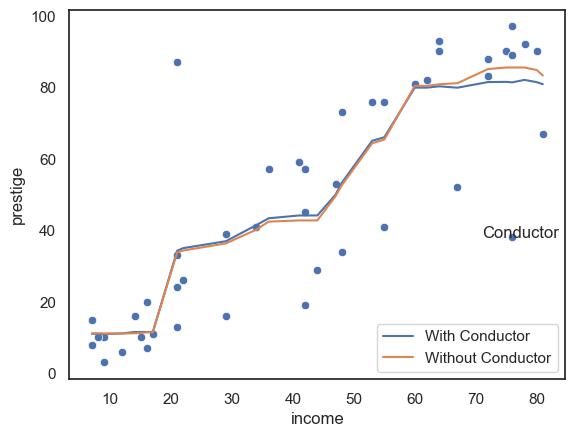

In [15]:
sns.scatterplot(data, x="income", y="prestige")
plt.annotate("Conductor", (data.loc["conductor", "income"]-5, data.loc["conductor", "prestige"]), fontsize=12)
sns.lineplot(Pred, x=0, y=1, legend='brief', label='With Conductor')
sns.lineplot(Pred_2, x=0, y=1, legend='brief', label='Without Conductor')
plt.legend()


Calculate residuals.

In [16]:
resid_rf = np.array(y - clf.predict(X))

And SHAP values.

In [17]:
explainer_rf = shap.TreeExplainer(clf, X)
shap_values_rf = explainer_rf.shap_values(X)

## Influential outlier metric

We calculate our influence metric for the linear case and the non-linear case.

In [18]:
print(f"SHAP values: {stats.shapiro(shap_values.reshape(-1)).pvalue:.4f}")
print(f"Residuals: {stats.shapiro(resid.reshape(-1)).pvalue:.4f}")

SHAP values: 0.0049
Residuals: 0.0142


In [19]:
iom_lr = InfluentialOutlierMetric(shap_values, resid,
                                  1, 2, 2, 
                                  1, 2, 2, 
                                  lambdas=np.concatenate([[0], np.exp(np.linspace(-1, 10, 50))]),
                                  lambdas_resid=np.concatenate([[0], np.exp(np.linspace(1, 10, 50))]),
                                  epoch=500, epoch_resid=500)

In [20]:
# Tune for lambda
iom_lr.find_best_lambda(alpha=0.05)
iom_lr.find_best_lambda_resid(alpha=0.05)

# Compute thresholds
thresholds = iom_lr.find_threshold(alpha=[0.05, 0.01])

# Compute IOM
IOM_lr = iom_lr.IOM()

Finding λ for SHAP values
Shapiro p-value = 0.0049
λ=0.0000


Normalizing flow: 100%|██████████| 500/500 [00:05<00:00, 96.51it/s] 


p=0.5997
---
λ=0.3679


Normalizing flow: 100%|██████████| 500/500 [00:07<00:00, 63.48it/s]


p=0.1710
---
λ=0.4605


Normalizing flow: 100%|██████████| 500/500 [00:07<00:00, 67.96it/s]


p=0.1238
---
λ=0.5764


Normalizing flow: 100%|██████████| 500/500 [00:06<00:00, 79.18it/s]


p=0.0867
---
λ=0.7214


Normalizing flow: 100%|██████████| 500/500 [00:08<00:00, 59.91it/s]


p=0.0608
---
λ=0.9030


Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 30.81it/s]


p=0.0433
---
Selected λ=0.7214, p=0.0608
Done!
Finding λ for residuals
Shapiro p-value = 0.0142
λ=0.0000


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.44it/s]


p=0.9943
---
λ=2.7183


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 47.03it/s]


p=0.3811
---
λ=3.2664


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 49.15it/s]


p=0.3446
---
λ=3.9249


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 49.18it/s]


p=0.3121
---
λ=4.7163


Normalizing flow: 100%|██████████| 500/500 [00:09<00:00, 51.19it/s]


p=0.2875
---
λ=5.6672


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 48.23it/s]


p=0.2697
---
λ=6.8098


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 49.11it/s]


p=0.2559
---
λ=8.1829


Normalizing flow: 100%|██████████| 500/500 [00:10<00:00, 49.80it/s]


p=0.2454
---
λ=9.8327


Normalizing flow: 100%|██████████| 500/500 [00:11<00:00, 45.42it/s]


p=0.2385
---
λ=11.8152


Normalizing flow: 100%|██████████| 500/500 [00:09<00:00, 51.53it/s]


p=0.2163
---
λ=14.1974


Normalizing flow: 100%|██████████| 500/500 [00:07<00:00, 65.37it/s]


p=0.2057
---
λ=17.0600


Normalizing flow: 100%|██████████| 500/500 [00:09<00:00, 53.96it/s]


p=0.1973
---
λ=20.4997


Normalizing flow: 100%|██████████| 500/500 [00:07<00:00, 64.74it/s]


p=0.1914
---
λ=24.6329


Normalizing flow: 100%|██████████| 500/500 [00:08<00:00, 61.73it/s]


p=0.1877
---
λ=29.5994


Normalizing flow: 100%|██████████| 500/500 [00:08<00:00, 59.69it/s]


p=0.1862
---
λ=35.5674


Normalizing flow: 100%|██████████| 500/500 [00:07<00:00, 66.43it/s]


p=0.1580
---
λ=42.7386


Normalizing flow: 100%|██████████| 500/500 [00:07<00:00, 65.05it/s]


p=0.1344
---
λ=51.3557


Normalizing flow: 100%|██████████| 500/500 [00:07<00:00, 65.64it/s]


p=0.1165
---
λ=61.7102


Normalizing flow: 100%|██████████| 500/500 [00:07<00:00, 64.67it/s]


p=0.1008
---
λ=74.1524


Normalizing flow: 100%|██████████| 500/500 [00:08<00:00, 61.93it/s]


p=0.0866
---
λ=89.1033


Normalizing flow: 100%|██████████| 500/500 [00:08<00:00, 59.90it/s]


p=0.0740
---
λ=107.0686


Normalizing flow: 100%|██████████| 500/500 [00:08<00:00, 60.93it/s]


p=0.0632
---
λ=128.6561


Normalizing flow: 100%|██████████| 500/500 [00:07<00:00, 63.32it/s]


p=0.0539
---
λ=154.5962


Normalizing flow: 100%|██████████| 500/500 [00:08<00:00, 57.23it/s]

p=0.0461
---
Selected λ=128.6561, p=0.0539
Done!
Threshold at 0.05: 4.7609
Threshold at 0.01: 12.9904


### OLS

In [21]:
IOM_lr.index = data.index
print(f"Threshold at 0.05: {thresholds[0]:.4f}")
print(f"Threshold at 0.01: {thresholds[1]:.4f}")
IOM_lr.sort_values(ascending=False).round(2)

Threshold at 0.05: 4.7609
Threshold at 0.01: 12.9904


rownames
conductor             12.03
minister               4.93
RR.engineer            4.82
reporter               1.37
professor              0.98
physician              0.93
chemist                0.73
shoe.shiner            0.48
bartender              0.47
soda.clerk             0.38
insurance.agent        0.29
accountant             0.28
factory.owner          0.26
engineer               0.26
watchman               0.24
architect              0.24
gas.stn.attendant      0.24
truck.driver           0.22
banker                 0.22
coal.miner             0.20
store.clerk            0.17
author                 0.14
contractor             0.14
lawyer                 0.13
carpenter              0.10
mail.carrier           0.07
teacher                0.06
machinist              0.05
pilot                  0.04
taxi.driver            0.02
janitor                0.02
bookkeeper             0.02
dentist                0.02
cook                   0.01
plumber                0.01
waiter     

In [22]:
iom_lr.summary()

               Parameter      Value
             Samples (n)  45.000000
            Features (p)   1.000000
       Flow depth (SHAP)   1.000000
     Hidden units (SHAP)   2.000000
           Layers (SHAP)   2.000000
  Flow depth (Residuals)   1.000000
Hidden units (Residuals)   2.000000
      Layers (Residuals)   2.000000
          Final λ (SHAP)   0.721422
            Shap p-value   0.060800
     Final λ (Residuals) 128.656088
        Residual p-value   0.053936
      Threshold (α=0.05)   4.760901
      Threshold (α=0.01)  12.990353


,Parameter,Value
0,Samples (n),45.000000
1,Features (p),1.000000
2,Flow depth (SHAP),1.000000
3,Hidden units (SHAP),2.000000
4,Layers (SHAP),2.000000
5,Flow depth (Residuals),1.000000
6,Hidden units (Residuals),2.000000
7,Layers (Residuals),2.000000
8,Final λ (SHAP),0.721422
9,Shap p-value,0.060800


#### Cook's vs. IOM

In [23]:
cook_iom = pd.concat([pd.Series(outliers_influence.OLSInfluence(mod).cooks_distance[0], name='Cook'), 
                      IOM_lr], axis=1)

Text(0.08294158738991252, 4.815187171589672, 'RR.engineer')

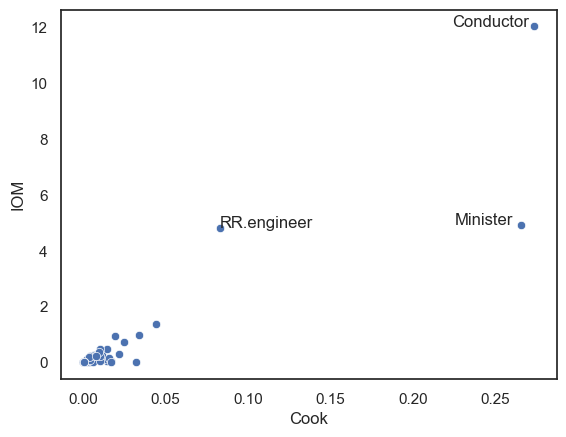

In [24]:
sns.scatterplot(cook_iom, x='Cook', y='IOM')
plt.annotate("Conductor", (cook_iom.loc["conductor", "Cook"]-0.05, cook_iom.loc["conductor", "IOM"]), fontsize=12)
plt.annotate("Minister", (cook_iom.loc["minister", "Cook"]-0.04, cook_iom.loc["minister", "IOM"]), fontsize=12)
plt.annotate("RR.engineer", (cook_iom.loc["RR.engineer", "Cook"], cook_iom.loc["RR.engineer", "IOM"]), fontsize=12)

### Random forest

We assess normality.

In [25]:
print(f"SHAP values: {stats.shapiro(shap_values_rf.reshape(-1)).pvalue:.4f}")
print(f"Residuals: {stats.shapiro(resid_rf.reshape(-1)).pvalue:.4f}")

SHAP values: 0.0001
Residuals: 0.0131


We reject the null hypothesis of normality. Now we calculate our IOM.

In [26]:
iom_rf = InfluentialOutlierMetric(shap_values, resid,
                                  2, 1, 2, 
                                  2, 1, 2, 
                                  lambdas=np.concatenate([[0], np.exp(np.linspace(-5, 5, 50))]),
                                  lambdas_resid=np.concatenate([[0], np.exp(np.linspace(1, 10, 50))]),
                                  epoch=500, epoch_resid=500)

In [27]:
# Tune for lambda
iom_rf.find_best_lambda(alpha=0.05)
iom_rf.find_best_lambda_resid(alpha=0.05)

# Compute thresholds
thresholds = iom_rf.find_threshold(alpha=[0.05, 0.01])

# Compute IOM
IOM_rf = iom_rf.IOM()

Finding λ for SHAP values
Shapiro p-value = 0.0049
λ=0.0000


Normalizing flow:   1%|          | 6/500 [00:00<00:17, 28.01it/s]

Normalizing flow: 100%|██████████| 500/500 [00:18<00:00, 27.34it/s]


p=0.8658
---
λ=0.0067


Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 30.52it/s]


p=0.8594
---
λ=0.0083


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 34.94it/s]


p=0.8585
---
λ=0.0101


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.56it/s]


p=0.8561
---
λ=0.0124


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 33.27it/s]


p=0.8559
---
λ=0.0152


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 35.68it/s]


p=0.8524
---
λ=0.0187


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.13it/s]


p=0.8466
---
λ=0.0229


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 33.93it/s]


p=0.8432
---
λ=0.0281


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 31.96it/s]


p=0.8368
---
λ=0.0345


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.79it/s]


p=0.8313
---
λ=0.0423


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.84it/s]


p=0.8207
---
λ=0.0519


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.35it/s]


p=0.8076
---
λ=0.0636


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.81it/s]


p=0.7924
---
λ=0.0780


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.19it/s]


p=0.7704
---
λ=0.0957


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.51it/s]


p=0.7427
---
λ=0.1173


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.55it/s]


p=0.7059
---
λ=0.1439


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.94it/s]


p=0.6540
---
λ=0.1765


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.75it/s]


p=0.5857
---
λ=0.2164


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.76it/s]


p=0.4948
---
λ=0.2654


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 35.18it/s]


p=0.3966
---
λ=0.3255


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 33.42it/s]


p=0.2956
---
λ=0.3992


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 32.92it/s]


p=0.2102
---
λ=0.4895


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 33.48it/s]


p=0.1425
---
λ=0.6004


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 35.49it/s]


p=0.0957
---
λ=0.7363


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.76it/s]


p=0.0659
---
λ=0.9030


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 33.22it/s]


p=0.0469
---
Selected λ=0.7363, p=0.0659
Done!
Finding λ for residuals
Shapiro p-value = 0.0142
λ=0.0000


Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 29.59it/s]


p=0.9996
---
λ=2.7183


Normalizing flow: 100%|██████████| 500/500 [00:18<00:00, 26.94it/s]


p=0.8171
---
λ=3.2664


Normalizing flow: 100%|██████████| 500/500 [00:15<00:00, 31.79it/s]


p=0.8000
---
λ=3.9249


Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 31.11it/s]


p=0.7898
---
λ=4.7163


Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 30.26it/s]


p=0.7767
---
λ=5.6672


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.51it/s]


p=0.7493
---
λ=6.8098


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.58it/s]


p=0.7235
---
λ=8.1829


Normalizing flow: 100%|██████████| 500/500 [00:16<00:00, 30.18it/s]


p=0.6949
---
λ=9.8327


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 35.05it/s]


p=0.6453
---
λ=11.8152


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.41it/s]


p=0.3126
---
λ=14.1974


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 35.94it/s]


p=0.2184
---
λ=17.0600


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.22it/s]


p=0.2161
---
λ=20.4997


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 35.04it/s]


p=0.2115
---
λ=24.6329


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 36.62it/s]


p=0.2106
---
λ=29.5994


Normalizing flow: 100%|██████████| 500/500 [00:14<00:00, 34.98it/s]


p=0.2121
---
λ=35.5674


Normalizing flow: 100%|██████████| 500/500 [00:12<00:00, 40.55it/s]


p=0.2029
---
λ=42.7386


Normalizing flow: 100%|██████████| 500/500 [00:12<00:00, 41.08it/s]


p=0.1763
---
λ=51.3557


Normalizing flow: 100%|██████████| 500/500 [00:11<00:00, 41.89it/s]


p=0.1627
---
λ=61.7102


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.10it/s]


p=0.1497
---
λ=74.1524


Normalizing flow: 100%|██████████| 500/500 [00:12<00:00, 38.99it/s]


p=0.1262
---
λ=89.1033


Normalizing flow: 100%|██████████| 500/500 [00:12<00:00, 40.47it/s]


p=0.1013
---
λ=107.0686


Normalizing flow: 100%|██████████| 500/500 [00:13<00:00, 37.37it/s]


p=0.0819
---
λ=128.6561


Normalizing flow: 100%|██████████| 500/500 [00:12<00:00, 38.59it/s]


p=0.0670
---
λ=154.5962


Normalizing flow: 100%|██████████| 500/500 [00:12<00:00, 39.20it/s]


p=0.0555
---
λ=185.7664


Normalizing flow: 100%|██████████| 500/500 [00:12<00:00, 41.09it/s]

p=0.0466
---
Selected λ=154.5962, p=0.0555
Done!
Threshold at 0.05: 4.7609
Threshold at 0.01: 12.9904


In [28]:
IOM_rf.index = data.index
print(f"Threshold at 0.05: {thresholds[0]:.4f}")
print(f"Threshold at 0.01: {thresholds[1]:.4f}")
IOM_rf.sort_values(ascending=False).round(2)

Threshold at 0.05: 4.7609
Threshold at 0.01: 12.9904


rownames
conductor             11.93
minister               4.76
RR.engineer            4.67
reporter               1.37
professor              0.97
physician              0.90
chemist                0.72
shoe.shiner            0.48
bartender              0.46
soda.clerk             0.37
insurance.agent        0.30
accountant             0.27
factory.owner          0.26
engineer               0.25
watchman               0.24
gas.stn.attendant      0.23
architect              0.23
truck.driver           0.22
banker                 0.21
coal.miner             0.19
store.clerk            0.17
author                 0.14
contractor             0.14
lawyer                 0.12
carpenter              0.10
mail.carrier           0.07
teacher                0.06
machinist              0.05
pilot                  0.03
janitor                0.02
taxi.driver            0.02
bookkeeper             0.02
dentist                0.01
plumber                0.01
cook                   0.01
waiter     

In [29]:
iom_rf.summary()

               Parameter      Value
             Samples (n)  45.000000
            Features (p)   1.000000
       Flow depth (SHAP)   2.000000
     Hidden units (SHAP)   2.000000
           Layers (SHAP)   1.000000
  Flow depth (Residuals)   2.000000
Hidden units (Residuals)   2.000000
      Layers (Residuals)   1.000000
          Final λ (SHAP)   0.736296
            Shap p-value   0.065936
     Final λ (Residuals) 154.596164
        Residual p-value   0.055528
      Threshold (α=0.05)   4.760901
      Threshold (α=0.01)  12.990353


,Parameter,Value
0,Samples (n),45.000000
1,Features (p),1.000000
2,Flow depth (SHAP),2.000000
3,Hidden units (SHAP),2.000000
4,Layers (SHAP),1.000000
5,Flow depth (Residuals),2.000000
6,Hidden units (Residuals),2.000000
7,Layers (Residuals),1.000000
8,Final λ (SHAP),0.736296
9,Shap p-value,0.065936
